In [19]:
import pandas as pd

data_path = "../resources/세종시_공동주택_현황.xlsx"

df = pd.read_excel(data_path)

df.head()

,연번,연번.1,예정지역내외,단지수,생활권,블럭명,아파트명,단지명,대지위치,도로명 주소,...,관리사무소(연락처),팩스,사업승인일(허가일),착공일,사용승인일,사용검사일,난방방식,지하주차장 유무,물막이판 유무,비고
0,합계,NaN,NaN,264,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"O: 238개소, X: 26개소",22개소,NaN
1,1,1.0,예정지역외(비의무),1,NaN,연립,명동연립,명동연립,조치원읍,장안2길 37,...,NaN,NaN,1981.03.08.,1982.09.24.,1988.12.31.,1982.09.24.,NaN,X,NaN,NaN
2,2,2.0,예정지역외(비의무),1,NaN,연립,고려연립,고려연립,조치원읍,"건강길 27,29,31,건강1길51",...,NaN,NaN,1982.08.31.,1983.05.18.,1984.11.28.\n,1983.05.18.,NaN,X,NaN,NaN
3,3,3.0,예정지역외(비의무),1,NaN,연립,신흥주공연립,신흥주공연립,조치원읍,군청로 117,...,NaN,NaN,1983.08.19.,1984.09.20.,1984.09.29.,1984.09.20.,NaN,X,NaN,NaN
4,4,4.0,예정지역외(비의무),1,NaN,연립,제일연립,제일연립,조치원읍,조치원7길 88,...,NaN,NaN,1983.11.24.,1988.06.30.,1988.06.30.,1988.06.30.,NaN,X,NaN,NaN


In [20]:
# 합계 행 제거
df = df[df["연번"] != "합계"].copy()

# 필요한 컬럼만 추출
apt_df = df[[
    "아파트명",
    "단지명",
    "대지위치",
    "도로명 주소",
    "주차면수",
    "세대수",
    "동수",
    "분양/임대"
]].copy()

# 대지위치를 지역 컬럼으로 사용
apt_df["지역"] = apt_df["대지위치"]

apt_df.head()

,아파트명,단지명,대지위치,도로명 주소,주차면수,세대수,동수,분양/임대,지역
1,명동연립,명동연립,조치원읍,장안2길 37,-,24,2,분양,조치원읍
2,고려연립,고려연립,조치원읍,"건강길 27,29,31,건강1길51",-,72,4,분양,조치원읍
3,신흥주공연립,신흥주공연립,조치원읍,군청로 117,-,126,8,분양,조치원읍
4,제일연립,제일연립,조치원읍,조치원7길 88,-,84,5,분양,조치원읍
5,서창연립,서창연립,조치원읍,원마루길 33,-,24,1,분양,조치원읍


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("API_KEY")

api_key = api_key.strip()
print(api_key[:5], api_key[-5:])
print(len(api_key))

API_KEY 불러오기 성공
devU0 yODA=
43


In [32]:
def get_emd_name(address, api_key):
    url = "https://business.juso.go.kr/addrlink/addrLinkApi.do"

    params = {
        "currentPage": 1,
        "countPerPage": 1,
        "keyword": address,
        "confmKey": api_key,
        "resultType": "json"
    }

    try:
        response = requests.get(url, params=params)

        if response.status_code == 200:
            data = response.json()
            juso_list = data.get("results", {}).get("juso", [])

            if juso_list:
                return juso_list[0].get("emdNm", "정보 없음")
            else:
                return "정보 없음"

        return "정보 없음"

    except Exception as e:
        return f"오류({str(e)})"

In [33]:
data_path = "../resources/세종시_공동주택_현황.xlsx"

df = pd.read_excel(data_path)

# 합계 행 제거
df = df[df["연번"] != "합계"].copy()

apt_df = df[[
    "아파트명",
    "단지명",
    "대지위치",
    "도로명 주소",
    "주차면수",
    "세대수",
    "동수",
    "분양/임대"
]].copy()

In [34]:
apt_df["검색주소"] = (
    "세종특별자치시 "
    + apt_df["대지위치"].astype(str).str.strip()
    + " "
    + apt_df["도로명 주소"].astype(str).str.strip()
)

apt_df[["대지위치", "도로명 주소", "검색주소"]].head()

,대지위치,도로명 주소,검색주소
1,조치원읍,장안2길 37,세종특별자치시 조치원읍 장안2길 37
2,조치원읍,"건강길 27,29,31,건강1길51","세종특별자치시 조치원읍 건강길 27,29,31,건강1길51"
3,조치원읍,군청로 117,세종특별자치시 조치원읍 군청로 117
4,조치원읍,조치원7길 88,세종특별자치시 조치원읍 조치원7길 88
5,조치원읍,원마루길 33,세종특별자치시 조치원읍 원마루길 33


In [35]:
apt_df["지역_API"] = apt_df["검색주소"].apply(lambda x: get_emd_name(x, api_key))

apt_df[["아파트명", "대지위치", "검색주소", "지역_API"]].head(20)

,아파트명,대지위치,검색주소,지역_API
1,명동연립,조치원읍,세종특별자치시 조치원읍 장안2길 37,조치원읍
2,고려연립,조치원읍,"세종특별자치시 조치원읍 건강길 27,29,31,건강1길51",정보 없음
3,신흥주공연립,조치원읍,세종특별자치시 조치원읍 군청로 117,조치원읍
4,제일연립,조치원읍,세종특별자치시 조치원읍 조치원7길 88,조치원읍
5,서창연립,조치원읍,세종특별자치시 조치원읍 원마루길 33,조치원읍
6,유성연립(경남빌라),부강면,세종특별자치시 부강면 부강로 5,부강면
7,대광아파트,부강면,세종특별자치시 부강면 부강신대길 56-17,부강면
8,삼호아파트,부강면,세종특별자치시 부강면 부강신대길 53,부강면
9,팔팔아파트,부강면,세종특별자치시 부강면 시장1길 34,부강면
10,두진한라아파트,조치원읍,세종특별자치시 조치원읍 모과나무7길 17,조치원읍


In [37]:
missing_values = apt_df[apt_df["지역_API"] == "정보 없음"]
apt_df["지역"] = apt_df["지역_API"]

apt_df.loc[apt_df["지역"] == "정보 없음", "지역"] = apt_df["대지위치"]

apt_df[["아파트명", "대지위치", "검색주소", "지역_API", "지역"]].head(20)
missing_values[["아파트명", "단지명", "검색주소", "대지위치", "지역_API"]]

,아파트명,단지명,검색주소,대지위치,지역_API
2,고려연립,고려연립,"세종특별자치시 조치원읍 건강길 27,29,31,건강1길51",조치원읍,정보 없음
45,민석그린,민석그린,세종특별자치시 장군면 운주산로 1398,장군면,정보 없음


In [39]:
apt_df["주차면수"] = pd.to_numeric(apt_df["주차면수"], errors="coerce").fillna(0)
apt_df["세대수"] = pd.to_numeric(apt_df["세대수"], errors="coerce").fillna(0)
apt_df["동수"] = pd.to_numeric(apt_df["동수"], errors="coerce").fillna(0)


apt_summary = apt_df.groupby("지역").agg({
    "아파트명": "count",
    "세대수": "sum",
    "주차면수": "sum",
    "동수": "sum"
}).rename(columns={
    "아파트명": "공동주택수",
    "세대수": "총세대수",
    "주차면수": "총주차면수",
    "동수": "총동수"
}).reset_index()

apt_summary = apt_summary.sort_values(by="총세대수", ascending=False)

apt_summary

,지역,공동주택수,총세대수,총주차면수,총동수
20,조치원읍,44,13015,11964.0,193
0,고운동,22,12551,17433.0,242
21,종촌동,12,11251,13725.0,166
3,다정동,12,11070,14928.0,210
5,도담동,24,10399,13091.0,158
10,새롬동,14,9937,14066.0,156
11,소담동,11,8574,11903.0,109
13,아름동,11,8008,10272.0,123
7,보람동,12,7189,10720.0,117
6,반곡동,12,6689,9238.0,156


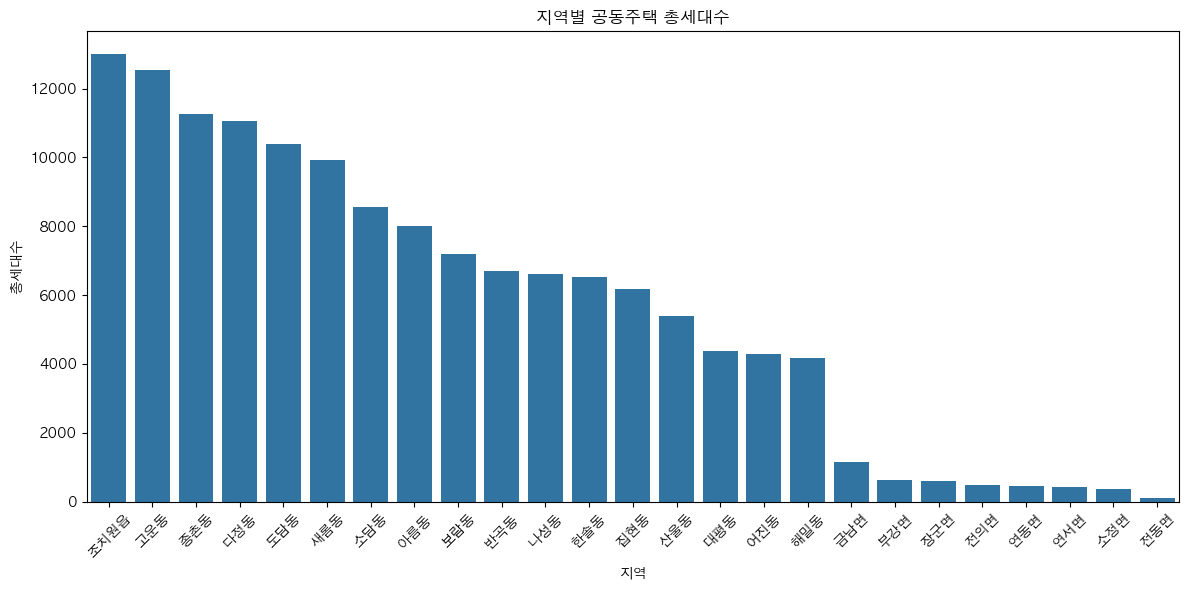

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(12, 6))

top_apt = apt_summary.sort_values(by="총세대수", ascending=False)

sns.barplot(data=top_apt, x="지역", y="총세대수")

plt.title("지역별 공동주택 총세대수")
plt.xlabel("지역")
plt.ylabel("총세대수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()